In [9]:
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
import matplotlib.pyplot as plt
from IPython import display

class Animator:
    """在 Jupyter 训练循环中实时刷新曲线。分类任务用双子图：上 loss、下 acc。"""

    def __init__(self, xlabel='epoch', xlim=None,
                 loss_legend=None, acc_legend=None, acc_ylim=(0, 1),
                 fmts=('-', 'm--', 'g-.', 'r:', 'c-', 'y--', 'k-.', 'b:'),
                 figsize=(5, 6)):
        self.xlabel = xlabel
        self.xlim = xlim
        self.loss_legend = list(loss_legend) if loss_legend else []
        self.acc_legend = list(acc_legend) if acc_legend else []
        self.acc_ylim = acc_ylim
        self.fmts = list(fmts)
        self.loss_X, self.loss_Y = None, None
        self.acc_X, self.acc_Y = None, None

        if self.acc_legend:
            self.fig, (self.ax_loss, self.ax_acc) = plt.subplots(
                2, 1, figsize=figsize, sharex=True)
        else:
            self.fig, self.ax_loss = plt.subplots(1, 1, figsize=(figsize[0], figsize[1] / 2))
            self.ax_acc = None

    @staticmethod
    def _as_lines(values):
        if values is None:
            return []
        if isinstance(values, (list, tuple)):
            return list(values)
        return [values]

    def _ensure_lines(self, storage, n):
        X, Y = storage
        if X is None:
            return [[] for _ in range(n)], [[] for _ in range(n)]
        if n > len(X):
            X.extend([] for _ in range(n - len(X)))
            Y.extend([] for _ in range(n - len(Y)))
        return X, Y

    def _append_points(self, storage, x, values):
        values = self._as_lines(values)
        if not values:
            return storage
        x = self._as_lines(x)
        if len(x) == 1:
            x = x * len(values)
        elif len(x) != len(values):
            raise ValueError(
                f'x 与 values 长度不一致: len(x)={len(x)}, len(values)={len(values)}'
            )
        X, Y = self._ensure_lines(storage, len(values))
        for i, (xi, yi) in enumerate(zip(x, values)):
            if xi is not None and yi is not None:
                X[i].append(xi)
                Y[i].append(yi)
        return X, Y

    def _plot_panel(self, ax, X, Y, legend, ylim=None, show_xlabel=False):
        ax.cla()
        if X is None:
            return
        for i, (xs, ys) in enumerate(zip(X, Y)):
            fmt = self.fmts[i % len(self.fmts)]
            label = legend[i] if i < len(legend) else None
            ax.plot(xs, ys, fmt, label=label)
        if self.xlim:
            ax.set_xlim(self.xlim)
        if ylim:
            ax.set_ylim(ylim)
        if show_xlabel and self.xlabel:
            ax.set_xlabel(self.xlabel)
        if legend:
            ax.legend(legend)
        ax.grid(True)

    def add(self, x, loss=None, acc=None):
        """追加数据并重绘。分类: add(epoch, loss=(tr, te), acc=(tr, te))。"""
        self.loss_X, self.loss_Y = self._append_points(
            (self.loss_X, self.loss_Y), x, loss)
        if self.ax_acc is not None:
            self.acc_X, self.acc_Y = self._append_points(
                (self.acc_X, self.acc_Y), x, acc)

        self._plot_panel(self.ax_loss, self.loss_X, self.loss_Y,
                         self.loss_legend, show_xlabel=self.ax_acc is None)
        if self.ax_acc is not None:
            self._plot_panel(self.ax_acc, self.acc_X, self.acc_Y,
                             self.acc_legend, ylim=self.acc_ylim, show_xlabel=True)

        self.fig.tight_layout()
        display.clear_output(wait=True)
        display.display(self.fig)

    def close(self):
        plt.close(self.fig)
def train_cnn(net, train_iter, test_iter, loss=None, optimizer=None, num_epochs=10, lr=0.01, device=None, task='classification'):
    if loss is None:
        loss = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    net = net.to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    if task == 'classification':
        animator = Animator(
            xlabel='epoch', xlim=[1, num_epochs],
            loss_legend=['train loss', 'test loss'],
            acc_legend=['train acc', 'test acc'],
        )
    else:
        animator = Animator(
            xlabel='epoch', xlim=[1, num_epochs],
            loss_legend=['train loss', 'test loss'],
        )
    final_score = None

    for epoch in range(num_epochs):
        net.train()
        train_loss, train_acc, n = 0.0, 0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            bs = X.shape[0]
            train_loss += l.item() * bs
            n += bs
            if task == 'classification':
                train_acc += (y_hat.argmax(dim=1) == y).sum().item()

        train_loss /= n
        if task == 'classification':
            train_acc /= n

        net.eval()
        test_loss, test_acc, m = 0.0, 0, 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                bs = X.shape[0]
                test_loss += loss(y_hat, y).item() * bs
                m += bs
                if task == 'classification':
                    test_acc += (y_hat.argmax(dim=1) == y).sum().item()

        test_loss /= m
        if task == 'classification':
            test_acc /= m
            final_score = (train_loss, train_acc, test_loss, test_acc)
            animator.add(epoch + 1, loss=(train_loss, test_loss),
                         acc=(train_acc, test_acc))
        else:
            final_score = (train_loss, test_loss)
            animator.add(epoch + 1, loss=(train_loss, test_loss))
    animator.close()
    if task == 'classification':
        print(f"训练损失: {final_score[0]:.3f}, 训练准确率: {final_score[1]:.3f}, "
              f"测试损失: {final_score[2]:.3f}, 测试准确率: {final_score[3]:.3f}")
    else:
        print(f"训练损失: {final_score[0]:.3f}, 测试损失: {final_score[1]:.3f}")
    return final_score

import torchvision
from torchvision import transforms
from torch.utils import data

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    train_set = torchvision.datasets.FashionMNIST(
        './data', train=True, transform=trans, download=True)
    test_set = torchvision.datasets.FashionMNIST(
        './data', train=False, transform=trans, download=True)
    train_iter = data.DataLoader(train_set, batch_size, shuffle=True, num_workers=0)
    test_iter = data.DataLoader(test_set, batch_size, shuffle=False, num_workers=0)
    return train_iter, test_iter

train_iter, test_iter = load_data_fashion_mnist(128)

cuda


In [10]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    if not torch.is_grad_enabled():
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        X_hat = (X - mean) / torch.sqrt(var + eps)
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data


In [11]:
class BatchNorm(nn.Module):
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean, self.moving_var,
            eps=1e-5, momentum=0.9)
        return Y

In [12]:
class myLeNet(nn.Module):
    """LeNet for Fashion-MNIST (1x28x28). 使用标准 Conv2d/Linear，兼容 Colab 等环境。"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2), BatchNorm(6, 4), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, 4), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), BatchNorm(120, 2), nn.Sigmoid(),
            nn.Linear(120, 84), BatchNorm(84, 2), nn.Sigmoid(),
            nn.Linear(84, 10),
        )

    def forward(self, X):
        return self.net(X)

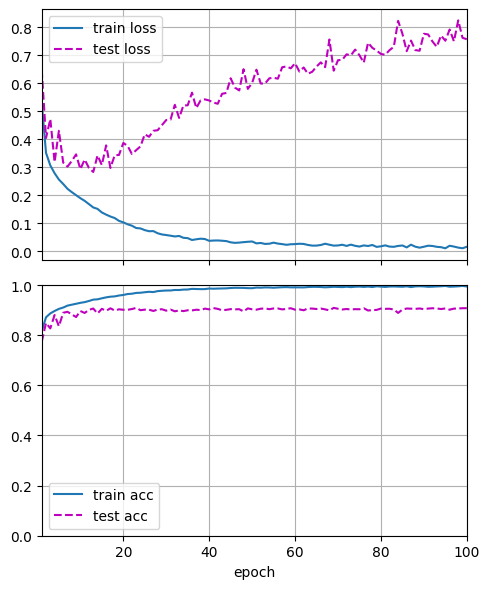

训练损失: 0.016, 训练准确率: 0.994, 测试损失: 0.756, 测试准确率: 0.908


(0.01598383219682922, 0.9943333333333333, 0.756391824054718, 0.9078)

In [14]:
net = myLeNet()
train_cnn(net, train_iter, test_iter, num_epochs=100)